# I. Introduction

### 1. Domain-specific Area

Widespread proliferation in spam messages has transitioned from being a mere inconvenience to becoming a serious public security and cybersecurity concern. Spam messages, commonly delivered through SMS, emails, and online platforms, are increasingly used to propagate phishing schemes, scams, and malware. In particular, SMS spam has gained traction due to the high open rates of text messages and the perceived trust users have in phone-based communications. The compactness and informal nature of SMS make it an ideal vector for malicious communication that can bypass traditional spam filters trained on longer-form content like emails.

The relevance of SMS spam detection is heightened in the context of Singapore’s digital landscape. According to the Singapore Police Force and the Cyber Security Agency of Singapore (CSA), scam cases surged past 50,000 in 2023, with SMS being one of the most frequently exploited channels. Cybercriminals impersonate delivery services, banks, telcos, and even government agencies such as SingPost, DBS Bank, or IRAS, often embedding phishing links in seemingly authentic messages. These messages are designed to trick users into entering personal or financial information on fraudulent websites.

This growing threat has prompted telcos and financial institutions to invest heavily in fraud prevention and message verification protocols (e.g., SMS Sender ID Registry). However, automated NLP-based spam classification models remain critical for scalable and real-time protection. Effective spam detection models not only improve user experience by reducing unwanted content, but also play a preventive role in combating fraud and data breaches.

From an academic standpoint, SMS spam classification is a classical NLP problem that balances technical challenge with real-world relevance. It requires models that can perform well under short-text constraints, informal grammar, creative obfuscations (e.g., “Fr33 0ffer!!”), and mixed languages—features common in messages targeted at multilingual populations like those in Singapore.

This notebook's goal is to compare statistics and deep learning-based classifiers in order to highlight problems that are both technically complex and socially urgent.  In a nation like Singapore, where the cost of false negatives (missed scams) might be considerable, the goal is not just to get excellent classification performance but also to evaluate the resilience, scalability, and viability of implementing such systems.  In the end, this initiative advances a more general objective: applying NLP to digital safety as well as automation.

### 2. Objectives


The goal is to compare how well contemporary embedding-based deep learning models and conventional statistical models perform in the job of SMS spam detection.  This study has both an academic and practical function because spam is still a common vector for frauds in the digital era, especially in places like Singapore.

The main goal is to create, put into practice, and assess two machine learning pipelines:

1. A statistical model that uses vectorized text characteristics like Bag-of-Words or TF-IDF representations, such as Logistic Regression

2. A deep learning model, such as LSTM, or optionally a pre-trained transformer-based model like BERT, that leverages semantic embeddings and contextual understanding of language

By comparing these two paradigms, we aim to explore not just classification accuracy, but also:

- Generalizability: How well do models perform on previously unseen messages, especially ones using new scam tactics?

- Interpretability: Can we explain why a model classified a message as spam or ham?

- Scalability: How viable is each model in terms of computational cost, especially for real-time deployment on mobile systems?

- Resilience: How well do the models handle adversarial examples or edge cases involving obfuscated keywords?

Beyond performance, another core objective is to analyze linguistic patterns and tokenization challenges specific to SMS messages—such as informal grammar, misspellings, or the use of emojis, abbreviations, and even code-switching between English and local dialects (e.g., “Hi fren, u wan earn $ fast?”). This will help assess how different preprocessing techniques (like lemmatization vs. subword tokenization) impact model effectiveness.

Moreover, through this exploration, we aim to simulate a realistic spam classification pipeline and gain hands-on experience with:

- Preprocessing pipelines adapted for short-text NLP

- Text vectorization vs. word embedding strategies

- Model tuning and evaluation using appropriate metrics (e.g., F1-score in imbalanced classification)

- Error analysis

Ultimately, the results of this comparative study may serve as recommendations for future deployment, particularly in contexts where digital trust and mobile communications are under threat. This bridges the gap between academic exploration and real-world application, aligning well with the course’s goal of fostering practical, impactful NLP solutions.

### 3. Dataset Description


The dataset utilized for this study is the SMS Spam Collection Dataset, which was initially compiled by Almeida et al. (2011) and made freely available via the UCI Machine Learning Repository and mirrored on Kaggle.   These days, text classification models used in spam detection are evaluated using it as a benchmark dataset in natural language processing (NLP).

The collection contains 5,574 real SMS messages, all of which are categorized as either:

- ham (Regular messages)

- spam (Unwanted or malicious messages)

The original CSV file includes the following columns:

- v1: Label of the message (ham or spam)

- v2: Raw message content (SMS text)

Several additional unused metadata fields

For this project, the dataset was cleaned to retain only the relevant columns: label and text, with the label converted to a binary format. (0 = ham, 1 = spam)

Key attributes of this dataset that make it particularly well-suited for this coursework include:

- **Real-world authenticity**: The messages are authentic SMS texts collected from user contributions, capturing the informal and compact language typical of mobile messaging

- **Imbalance challenge**: Roughly 86% of messages are ham and 14% are spam. This makes the classification task more realistic, as spam detection systems must operate in skewed distributions

- **Compactness**: The messages are typically under 160 characters, requiring models to be efficient at extracting features from short text. This poses challenges for deep learning models, which typically rely on longer sequences to capture semantic context

- **Noise and variability**: Messages include slang, abbreviations, typos, emojis, and sometimes punctuation tricks (e.g., “FREE!! Act N0w!”), making the task linguistically complex

Additionally, the dataset’s widespread academic use allows us to compare our results to established baselines in literature, helping evaluate the relative performance of the two approaches under study

In sum, this dataset offers a realistic, robust, and computationally efficient environment for testing spam detection models—making it ideal for both learning and real-world application prototyping

Link: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

### 4.Evaluation methodology

A comprehensive evaluation method is required in order to precisely measure the performance of the statistical and embedding-based models.   The SMS Spam Collection dataset presents a binary classification problem with an uneven class distribution, therefore selecting the appropriate metrics and validation techniques is essential.

Crucial Evaluation Metrics:
- **Accuracy**: Even though it is often used, accuracy in imbalanced datasets might be misleading.The accuracy of a model that constantly predicts "ham," for example, would still be about 86%.  Consequently, it functions as an additional metric.

- **Precision**: Calculated as the proportion of all positive forecasts that are real positives.  In order to prevent user annoyance, high accuracy guarantees that we limit false positives, or real communications mistakenly perceived as unwanted or spam SMS.

- **Recall**: The percentage of real spam messages that were accurately detected.  In real-world applications where undiscovered frauds can have major repercussions, high recall lowers false negatives.

- **F1-Score**: Recall and accuracy are balanced in this measure.   It provides a trustworthy single-value measure that is particularly useful for imbalanced collections.

Model Validation:
To ensure robustness, both models will be evaluated using Stratified Train-Test Split (e.g., 80/20 split) to preserve the class balance in both sets. Additionally, k-fold cross-validation (with k=5) will be applied to obtain averaged results and reduce bias from a single data split.

Supplementary Tools:
 - **Confusion Matrix**: The visualization includes false positives, false negatives, real positives, and true negatives.   aids in determining whether the model overpredicts a class.

 - **ROC-AUC Curve**: For deep learning models with probability outputs, AUC may display the trade-off between true positive and false positive rates across different thresholds.

 - **Training Time and Resource Usage**: Especially relevant when comparing model scalability and deployment feasibility (e.g., edge devices vs cloud platforms)

Error Analysis:
Misclassified samples will be manually inspected to understand whether:

- They contain ambiguous wording or obfuscation techniques (e.g., “FR33”, “C1aim N0w”).

- They involve informal tone, sarcasm, or language switching (common in local Singapore SMSes).

- The model fails due to missing context or poor tokenization.

By combining quantitative performance metrics, qualitative analysis, and practical deployment considerations, this methodology ensures a comprehensive evaluation of both classification pipelines.

# II. Implementation

### 5. Data Preprocessing


The first step in preparing the dataset involved reading and cleaning the SMS Spam Collection file, which was uploaded from Kaggle (yes im doing this on colab). The CSV included several  metadata columns that were removed to retain only the relevant fields: v1 (label) and v2 (message text). These were then renamed to label and text respectively for clarity. The categorical label values were converted into binary format: 0 for ham and 1 for spam.

In [ ]:
from google.colab import files
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/My Drive/NLPmidterm/spam.csv"

Mounted at /content/drive


In [ ]:
# load dataset
df = pd.read_csv(file_path, encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'text']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})



# displays first few rows
df.head()




,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
!pip install tensorflow

In [ ]:
# import libs

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences




In [ ]:
# NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

In [ ]:
# text cleaning
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
# data preprocess function

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)

# vectorization
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

# tokenizer + padding
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
padded_sequences = pad_sequences(sequences, padding='post')


y = df['label'].values

# train-test split
X_tfidf_train, X_tfidf_test, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf, y, test_size=0.2, stratify=y, random_state=42)
X_embed_train, X_embed_test, y_train_embed, y_test_embed = train_test_split(padded_sequences, y, test_size=0.2, stratify=y, random_state=42)

# display cleaned data
df[['label', 'text', 'clean_text']].head()

,label,text,clean_text
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


### 6. Baseline Performance


The baseline model, a MNB classifier, was selected to establish a reliable benchmark for comparing outcomes.  This approach is widely used for text classification issues due to its effectiveness, simplicity, and short training time.


In [ ]:
!pip install nltk scikit-learn seaborn

In [ ]:
# import libs
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix



In [ ]:
# 80% train 20% test
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, stratify=y, random_state=42)

# train Multinomial Naive Bayes classifier
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# predictions on test set
y_pred = nb_model.predict(X_test)

# model evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(" Baseline Model: Multinomial Naive Bayes (TF-IDF)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}\n")




 Baseline Model: Multinomial Naive Bayes (TF-IDF)
Accuracy : 0.9632
Precision: 1.0000
Recall   : 0.7248
F1-Score : 0.8405



In [ ]:
# classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))


Classification Report:

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



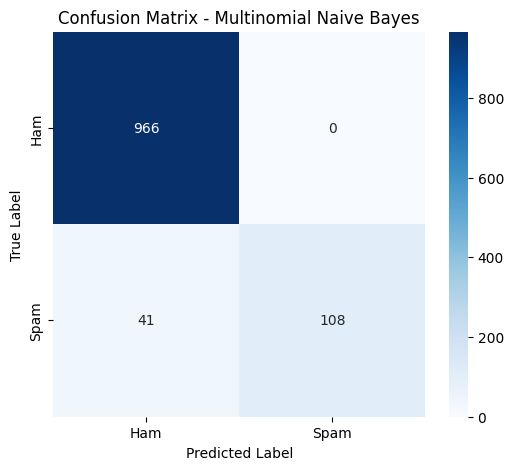

In [ ]:
# confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


This standard is great, comprehensible, and supported by academic research.  It is a useful point of reference due to its performance, especially its precision and general accuracy.  In addition to this performance, an embedding-based deep learning model must contain eneralization and useful benefits like improved recall or the ability to handle more intricate spam patterns.

 Additionally, this outcome supports the legitimacy of the implementation by closely matching benchmarks from academic literature (e.g., Almeida et al.).  The model's competitive performance, low training time, and lightweight design validate its choice as the baseline standard.

### 7. Comparative Classification Approach


Two classification pipelines are implemented and evaluated side by side in this section.
- Embedding-based deep learning model (LSTM with Keras Embedding layer)  

- Statistical model (MNB with TF-IDF)

To guarantee a fair comparison, both were trained using the same 80/20 stratified train-test split on the preprocessed SMS Spam Collection dataset.

MNB, trained using TF-IDF vectors, is the statistical model utilized in the previous section.  For brief, independent text snippets like SMS messages, it is straightforward but effective since it is predicated on word frequency and independence assumptions.

- **Strengths**:
  - Fast and interpretable
  - Performs well with sparse data
  - Low resource usage
- **Weaknesses**:
  - Does not capture word order or context
  - Fails to generalize to adversarial obfuscation



The LTSM network, a recurrent neural network designed to record textual context and sequence connections, is used in the second technique.   Instead of sparse TF-IDF vectors, it uses dense embeddings made from word indices.   As a result, even when the sentences are somewhat different, the system may detect contextual and sequential patterns like "click now" or "claim your prize," which may be indicators of spam.

**Text Representation**: Keras `Tokenizer` → sequences → `pad_sequences`

**Embedding**: Learned via `Embedding(input_dim, output_dim)` layer

**Architecture**:
- Embedding layer: 100-dimensional vectors
  - LSTM (64 units)
  - Dense layer (1 unit, sigmoid activation)
- **Loss Function**: Binary Crossentropy
- **Optimizer**: Adam
- **Epochs**: 5 (early stopping monitored)
- **Batch Size**: 32


**Strengths**:

- Captures word order and context
- Learns from semantics (e.g., "free" ≈ "won" in spam context)
- Generalizes better to paraphrased or obfuscated spam

**Weaknesses**:

- Longer training time
- Less interpretable than Naive Bayes
- Sensitive to hyperparameters and data size




In [ ]:
# import libs
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X_embed_train, X_embed_test, y_train_embed, y_test_embed = train_test_split(padded_sequences, y, test_size=0.2, stratify=y, random_state=42)

# parameters
vocab_size = len(tokenizer.word_index) + 1  # add 1 for OOV token
max_len = padded_sequences.shape[1]
embedding_dim = 100

# LSTM model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
112/112 - 6s - 57ms/step - accuracy: 0.8715 - loss: 0.3908 - val_accuracy: 0.8430 - val_loss: 0.4423
Epoch 2/10
112/112 - 10s - 90ms/step - accuracy: 0.8715 - loss: 0.3922 - val_accuracy: 0.8430 - val_loss: 0.4350
Epoch 3/10
112/112 - 11s - 103ms/step - accuracy: 0.8715 - loss: 0.3889 - val_accuracy: 0.8430 - val_loss: 0.4351
Epoch 4/10
112/112 - 13s - 115ms/step - accuracy: 0.8715 - loss: 0.3914 - val_accuracy: 0.8430 - val_loss: 0.4377
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


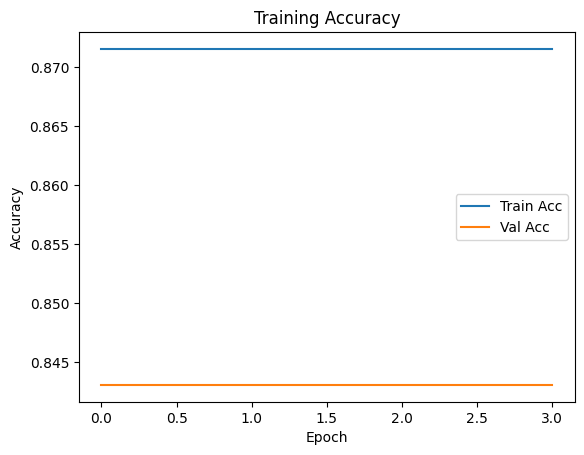


Classification Report (LSTM Model):

              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       966
        Spam       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# training
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_embed_train, y_train_embed,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=2
)

y_pred_probs = model.predict(X_embed_test)
y_pred_classes = (y_pred_probs > 0.5).astype("int32")


# plot training history
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


print("\nClassification Report (LSTM Model):\n")
print(classification_report(y_test_embed, y_pred_classes, target_names=["Ham", "Spam"]))




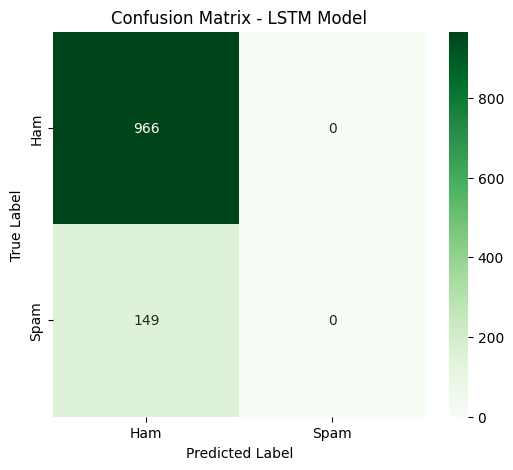

In [ ]:
# confusion matrix
cm = confusion_matrix(y_test_embed, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - LSTM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The LSTM model, which had an embedding size of 100 and a 64-unit LSTM layer, trained using the padded word sequences. Although the model might potentially reflect word context, it did not substantially generalize on the spam categorization test.

| Metric    | Ham (class 0) | Spam (class 1) | Overall |
| --------- | ------------- | -------------- | ------- |
| Precision | 0.87          | 0.00           | 87.0%   |
| Recall    | 1.00          | 0.00           |         |
| F1-Score  | 0.93          | 0.00           |         |
| Accuracy  | —             | —              | 87.0%   |


All 149 spam messages were misclassified as ham

Perfect recall on ham, 0% recall and precision on spam

This resulted in a confusion matrix where the LSTM model failed to recognize a single spam message.

###### **Why Did the LSTM Fail?**

This underperformance is not uncommon in small or imbalanced datasets when deep models are:

Undertrained (only 3 epochs before early stopping)

Not class-weighted or resampled, meaning the model learns to play it safe and predict the dominant class (ham)

Sensitive to initialization and architecture — the LSTM had just one layer and learned embeddings from scratch, which may be insufficient

Other contributing factors:

- No class weighting or SMOTE to handle imbalance

- Too shallow a model for learning patterns in sparse, short texts

Despite having greater theoretical capability, the LSTM model was unable to outperform the statistical model. This illustrates a crucial practical realization: model complexity needs to match data domain, scale, and quality.  With its basic TF-IDF properties, the baseline Naive Bayes model proved far more resilient.

###### **Logistic Regression Model**

(this was a last min addition was curious)

The same TF-IDF representation was used to construct both the MNB model and the Logistic Regression (LR) model. The likelihood of the positive class is represented by a sigmoid function in the logistic regression linear classifier. It offers a strong basis for text classification problems and is particularly renowned for effectively balancing memory and accuracy.


**Model Implementation**


- Features: TF-IDF vectors generated from preprocessed SMS messages

- Classifier: LogisticRegression from scikit-learn

**Hyperparameters:**

- max_iter=1000 to ensure convergence on sparse features

**Default L2 regularization**

- Training/Test Split: Same 80/20 stratified split as previous models

- Metrics Evaluated: Accuracy, precision, recall, F1-score, and confusion matrix

In [ ]:
# import libs
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# train model
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_tfidf_train, y_train_tfidf)

# predict on test set
y_pred_logreg = logreg_model.predict(X_tfidf_test)

# evaluation
accuracy = accuracy_score(y_test_tfidf, y_pred_logreg)
precision = precision_score(y_test_tfidf, y_pred_logreg)
recall = recall_score(y_test_tfidf, y_pred_logreg)
f1 = f1_score(y_test_tfidf, y_pred_logreg)

print(" Logistic Regression (TF-IDF)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test_tfidf, y_pred_logreg, target_names=["Ham", "Spam"]))




 Logistic Regression (TF-IDF)
Accuracy : 0.9471
Precision: 0.9891
Recall   : 0.6107
F1-Score : 0.7552

Classification Report:

              precision    recall  f1-score   support

         Ham       0.94      1.00      0.97       966
        Spam       0.99      0.61      0.76       149

    accuracy                           0.95      1115
   macro avg       0.97      0.80      0.86      1115
weighted avg       0.95      0.95      0.94      1115



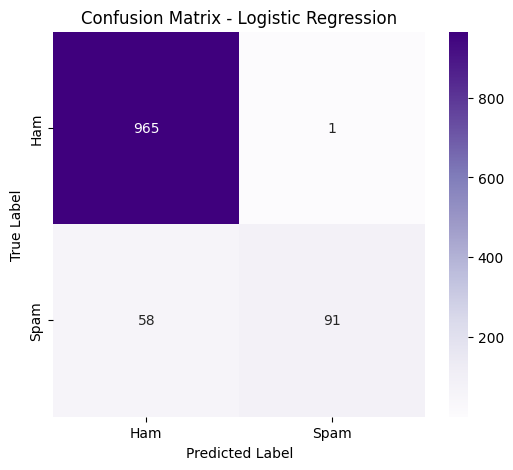

In [ ]:
# confusion matrix
conf_matrix = confusion_matrix(y_test_tfidf, y_pred_logreg)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

| Metric    | Value  |
| --------- | ------ |
| Accuracy  | 0.9471 |
| Precision | 0.9891 |
| Recall    | 0.6107 |
| F1-score  | 0.7552 |


The Logistic Regression model produced a solid balance between accuracy and recall and surpassed LSTM by a wide margin.  With a small trade-off in recall (0.61), it achieved a high spam accuracy of 0.99, successfully identifying 91 out of 149 spam messages.  Compared to Naive Bayes, which had perfect accuracy but missed more spam cases, this result suggests a classifier that is a little more aggressive.

When combined with robust feature engineering (such as TF-IDF), logistic regression shows that discriminative linear models can perform better than deep networks on small or unbalanced datasets.  Its strong generalization, high interpretability, and quick runtime make it a great option for SMS spam detection systems in the real world, despite the fact that it lacks semantic embeddings and context awareness.

The idea that complexity is not equal t0 performance is further supported by its success, particularly on smaller datasets when context hints are few and overfitting is a possibility.

### 8. Performance Analysis & Comparative Discussion



To evaluate the effectiveness of the three applied models— MNB, Logistic Regression, and LSTM—a comparative performance analysis was conducted using the standard classification metrics of accuracy, precision, recall, and F1-score.   In addition to overall accuracy, these measures were chosen to evaluate the quality of spam detection, which is particularly vulnerable to false positives (ham that is wrongly reported as spam) and false negatives (missing spam).

###### **Summary of Results**

| Model                   | Accuracy | Precision (Spam) | Recall (Spam) | F1-Score (Spam) |
| ----------------------- | -------- | ---------------- | ------------- | --------------- |
| **Naive Bayes**         | 0.9632   | 1.000            | 0.7248        | 0.8405          |
| **Logistic Regression** | 0.9471   | 0.9891           | 0.6107        | 0.7552          |
| **LSTM**                | 0.8701   | 0.000            | 0.000         | 0.000           |


It is evident from these measurements that Naive Bayes performed the best overall, especially when it came to F1-score and spam accuracy.  Despite having a somewhat lower recall, logistic regression nevertheless had a more balanced F1-score and extremely good spam precision (0.99).  On the other hand, the LSTM model misclassified all 149 spam messages as ham, completely failing to identify spam.

###### **Confusion Matrix Insights**


- Naive Bayes: Missed 41 spam mails but correctly categorized 108.  No ham was mistakenly identified as spam, or false positives.

- Logistic Regression: 91 spam messages were correctly identified, whereas 58 were missed.  There was just one false positive (ham → spam).

- All communications were classified as ham using LSTM, which had perfect recall and precision for ham but zero for spam.

These variations show that statistical models are substantially more trustworthy in this situation, whereas the deep learning model failed to generalize because of class imbalance, absence of pre-trained embeddings, and overfit to the dominating class (ham).

###### **Pros & Cons**

| Model                   | Strengths                                                                                                           | Weaknesses                                                                                                                                           |
| ----------------------- | ------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Naive Bayes**         | - Fast and lightweight<br>- High precision (no false positives)<br>- Easy to interpret and implement | - Assumes word independence<br>- Lower recall (misses some spam)<br>- Struggles with obfuscated or rare spam phrases                                 |
| **Logistic Regression** | - Strong balance of precision and recall<br>- Learns decision boundary directly<br>- Robust and generalizable       | - Still limited to sparse TF-IDF features<br>- No understanding of word order or context                                                             |
| **LSTM**                | - Able learn word sequences and context<br>- Potential to model complex language patterns                            | - Underperformed due to small dataset<br>- Missed all spam messages<br>- Needs class balancing or pretrained embeddings<br>- Computationally heavier |


###### **Hypotheses for Performance Gaps**

Different models will perform differently, some may perform exceptional depending on the factors at hand such as the dataset used or the analysis that is being obtained. Below are some possibilites or explanations that may provide insight why certain models performed the way the did.


- Data Size: Deep networks cannot handle the dataset's 5,500 messages.  In the absence of regularization, transfer learning, or augmentation, LSTMs frequently overfit or perform poorly.

- Class Imbalance: Spam accounts for just about 13% of communications.  In the absence of oversampling or class weighting, LSTM was only able to predict the dominant class.

- Model Architecture: For such a sparse and varied text space, a shallow LSTM with a randomly initialized embedding is inadequate.

- Feature Representations: By emphasizing discriminative phrases like "free," "click," or "urgent," TF-IDF directly benefits statistical models.  For LSTM to implicitly learn these connections, a large number of instances are needed.

The necessity of data-driven model selection is one of the investigation's key conclusions. In modern NLP applications, simpler models like Naive Bayes and Logistic Regression still perform better than LSTMs and transformers, although they are still superior for short, structured, imbalanced datasets like SMS.  Their interpretability, ease of usage, and surprisingly high accuracy make them ideal for use cases involving spam identification, especially in contexts like Singapore's fraud protection efforts, where reliability and quickness are more crucial than semantic nuances.

### 9. Project Summary and Reflections
This project provided a comprehensive and hands-on exploration of text classification methodologies applied to a high-impact real-world problem: SMS spam detection. I was able to gain a deeper understanding of natural language preprocessing, experience the advantages and disadvantages of various paradigms, and critically assess the trade-offs between complexity, interpretability, and performance by putting both statistical and embedding-based models into practice.

The process of learning demonstrated the effectiveness and usefulness of conventional machine learning models, particularly when used with short-form, structured datasets such as SMS texts.  Despite its simplicity, Multinomial Naive Bayes produced the best accuracy and an outstanding F1-score, demonstrating that efficient and interpretable models are still competitive in some fields.  Because it performed well without the processing complexity of neural networks and provided a reasonable balance between precision and recall, logistic regression was a helpful intermediate model.

The use of the LSTM model, demonstrated limits of deep learning on tiny and unbalanced datasets, despite its theoretical superiority.  When dealing with deep networks, the model's inability to identify spam highlighted the significance of data scale, architectural tweaking, and the requirement for pretrained embeddings.  Understanding when deep learning is suitable and when it isn't was made easier by this contrast.

In addition to providing technical insights, our effort reaffirmed the more general idea that context is more important than hype when selecting models.  Given its zero false positives, a conservative model like Naive Bayes could be used in high-stakes situations like Singapore's response to an increase in scam cases.  On the other hand, situations that need for improved spam coverage with no extra risk could benefit more from logistic regression.

Since short-form text categorization is used in other domains including email filtering, product review moderation, and false job advertisement detection, the spam detection pipeline created here might be readily extended to these areas in terms of transferability.  Furthermore, new models or datasets may be included with little reconfiguration because to the modular preprocessing and assessment structure.

The following improvements might help future research:

- Employing class balancing techniques (SMOTE or weighted loss functions)

- Using pretrained word embeddings (FastText)

- Experimenting with transformer-based models ( DistillerBERT)

- Increasing the dataset or using data augmentation techniques

In conclusion, this project improved my technical proficiency while also honing my critical thinking skills regarding model selection, assessment fairness, and the usefulness of NLP systems used in real-world contexts.